# 🏦 Bank Marketing Campaign
## 🌳 Model 2: Decision Tree

Decision Tree is a simple and powerful
classification algorithm. It splits the
data into branches based on feature values,
making decisions at each node until it
reaches a final prediction.

It predicts whether a customer will
subscribe to a term deposit or not.

#Install & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Step 1: Load Data

Loading the preprocessed data:

train.csv → Training data (after SMOTE) : (63870, 48)
test.csv  → Testing data (original)     : (9042, 48)

In [2]:
# Load Data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("✅ Data loaded successfully!")
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

✅ Data loaded successfully!
Train Shape: (63870, 48)
Test Shape: (9042, 48)


## ✂️ Step 2: Split Data

Splitting data into Features (X) and Target (y):

X_train → Features for training
y_train → Target for training
X_test  → Features for testing
y_test  → Target for testing

In [3]:
# Split Features and Target
X_train = train.drop('y', axis=1)
y_train = train['y']

X_test = test.drop('y', axis=1)
y_test = test['y']

print("✅ Split done successfully!")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

✅ Split done successfully!
X_train: (63870, 47)
y_train: (63870,)
X_test: (9042, 47)
y_test: (9042,)


## 🌳 Step 3: Train Decision Tree Model

Training the Decision Tree Classifier
on the training data.

In [4]:
from sklearn.tree import DecisionTreeClassifier

# Train Model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("✅ Decision Tree trained successfully!")

✅ Decision Tree trained successfully!


## 📊 Step 4: Model Evaluation

Evaluating the model on the test data
using Classification Report.

In [5]:
from sklearn.metrics import classification_report, accuracy_score

# Predictions
y_pred = dt_model.predict(X_test)

# Evaluation
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

✅ Accuracy: 0.8136474231364742

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      7984
           1       0.28      0.37      0.32      1058

    accuracy                           0.81      9042
   macro avg       0.59      0.62      0.60      9042
weighted avg       0.84      0.81      0.82      9042



## 🔢 Step 5: Confusion Matrix

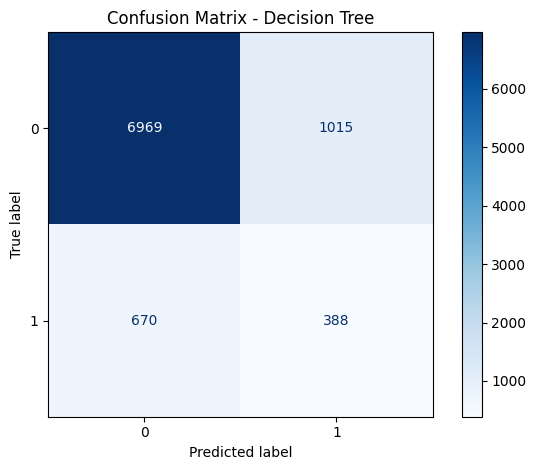

✅ Confusion Matrix saved!


In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.tight_layout()
plt.savefig('confusion_matrix_dt.png', dpi=150)
plt.show()

print("✅ Confusion Matrix saved!")

## 📈 Step 6: ROC Curve & AUC Score

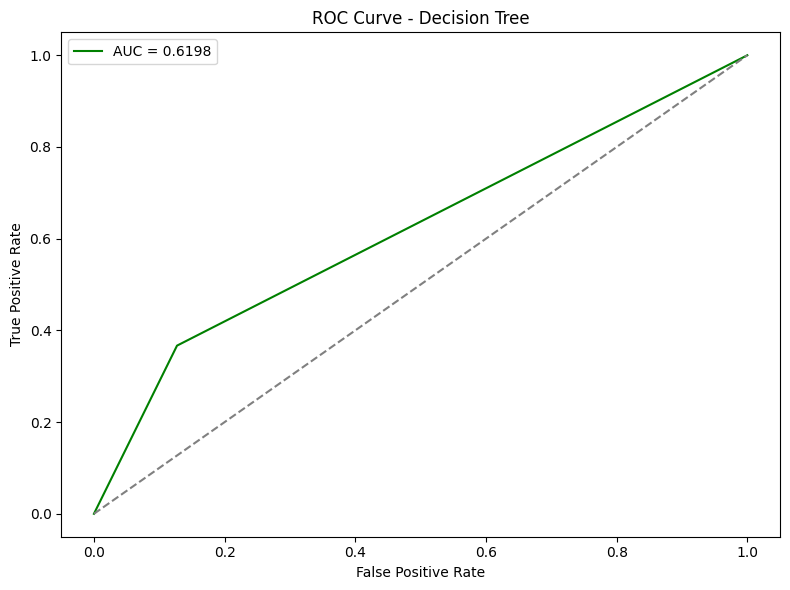

✅ AUC Score: 0.6198


In [7]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC Curve
y_prob = dt_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve_dt.png', dpi=150)
plt.show()

print(f"✅ AUC Score: {auc_score:.4f}")